# RetailPulse - Day 13: Automated Retraining Pipeline with Airflow
**Week:** 2 | **Day:** 13

---
## Objectives
1. Understand what Apache Airflow is and why MLOps pipelines need orchestration
2. Design the retraining pipeline as a sequence of tasks (DAG)
3. Write each pipeline step as a **plain, testable Python function** first
   (so it works with or without Airflow installed - good practice!)
4. Wrap those functions into an **Airflow DAG** using the modern TaskFlow API
5. Add a **drift-based conditional branch**: only retrain if Day 12's drift
   detector says retraining is needed
6. Add retries, alerting, and a model promotion / versioning step
7. Test the full pipeline logic locally (without needing a running Airflow server)
8. Save the DAG file in the format Airflow expects

---
## What is Apache Airflow and Why Do We Need It?

Until now, each notebook (Day 1-12) was something we ran MANUALLY, in order,
one cell at a time. In production, this does NOT scale:
- We can't manually re-run 12 notebooks every time new data arrives
- We need the pipeline to run on a SCHEDULE (e.g. every night)
- We need to know if/where a step FAILED, and automatically retry it
- We need clear VISIBILITY into how long each step takes and whether it succeeded

**Apache Airflow** solves this by letting us define a **DAG (Directed Acyclic
Graph)** - a pipeline of tasks with dependencies between them, that Airflow
schedules, runs, retries on failure, and monitors automatically via a web UI.

**Why 'Directed Acyclic Graph'?**
- **Directed**: tasks flow in one direction (A -> B -> C, not backwards)
- **Acyclic**: no loops/cycles (a task can't depend on itself, even indirectly)
- **Graph**: tasks (nodes) connected by dependencies (edges)

---
## Our Retraining Pipeline Design

```
check_for_new_data
        |
        v
run_drift_detection (reuses Day 12 logic)
        |
   should_retrain? (branching task)
      /        \
    YES         NO
     |           |
     v           v
retrain_models  skip_retraining (log + end)
     |
     v
evaluate_new_models
     |
     v
compare_with_production_model
     |
   better?
   /     \
 YES      NO
  |        |
  v        v
promote   keep_old_model
  |        |
  v        v
   send_notification
```

## Install Airflow
```bash
pip install apache-airflow
```
**NOTE:** Airflow is a heavy package that sets up its own metadata database and
web server - it's normally run as a separate SERVICE, not inside a Jupyter
notebook. Because of this, this notebook follows the recommended best practice:

1. We write and TEST all the pipeline logic as **plain Python functions** first,
   directly in this notebook (no Airflow needed to test the LOGIC).
2. We then show the exact **DAG file** you would save to Airflow's `dags/`
   folder to actually schedule and orchestrate this pipeline in production.


In [1]:
!pip install apache-airflow

  Using cached asgiref-3.11.1-py3-none-any.whl.metadata (9.3 kB)
  Using cached deprecated-1.3.1-py2.py3-none-any.whl.metadata (5.9 kB)
  Using cached msgspec-0.21.1-cp313-cp313-win_amd64.whl.metadata (5.9 kB)
INFO: pip is looking at multiple versions of fastapi[standard-no-fastapi-cloud-cli] to determine which version is compatible with other requirements. This could take a while.
  Using cached fastapi_cli-0.0.24-py3-none-any.whl.metadata (6.4 kB)
  Using cached email_validator-2.3.0-py3-none-any.whl.metadata (26 kB)
  Using cached dnspython-2.8.0-py3-none-any.whl.metadata (5.7 kB)
INFO: pip is looking at multiple versions of opentelemetry-exporter-otlp-proto-grpc to determine which version is compatible with other requirements. This could take a while.
  Using cached opentelemetry_exporter_otlp_proto_grpc-1.40.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached opentelemetry_exporter_otlp_proto_grpc-1.39.1-py3-none-any.whl.metadata (2.5 kB)
  Using cached opentelemetry_exporter_otlp

ERROR: Exception:
Traceback (most recent call last):
  File "D:\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "D:\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ~~~~~~~~~~~~~^^^^^
  File "D:\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ~~~~~~~~~~~~~^^^^^
  File "D:\anaconda3\Lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 98, in read
    data: bytes = self.__fp.read(amt)
                  ~~~~~~~~~~~~~~^^^^^
  File "D:\anaconda3\Lib\http\client.py", line 479, in read
    s = self.fp.read(amt)
  File "D:\anaconda3\Lib\socket.py", line 719, in readinto
    return self._sock.recv_into(b)
           ~~~~~~~~~~~~~~~~~~~~^^^
  File "D:\anaconda3\Lib\ssl.py", line 1304, in recv_into
    return self.r

In [2]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import json
import pickle
import os
import shutil
from datetime import datetime, timedelta

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

os.makedirs('../models', exist_ok=True)
os.makedirs('../models/production', exist_ok=True)
os.makedirs('../models/candidates', exist_ok=True)
os.makedirs('../models/archive', exist_ok=True)
os.makedirs('../logs', exist_ok=True)

pd.set_option('display.float_format', '{:.4f}'.format)

print('Libraries imported successfully')
print('Model registry folders created:')
print('  ../models/production/  <- currently LIVE model')
print('  ../models/candidates/  <- newly trained, not yet promoted')
print('  ../models/archive/     <- old retired models')


Libraries imported successfully
Model registry folders created:
  ../models/production/  <- currently LIVE model
  ../models/candidates/  <- newly trained, not yet promoted
  ../models/archive/     <- old retired models


## Step 1: Write Each Pipeline Stage as a Plain Python Function

**Why write plain functions first, instead of Airflow code directly?**
- We can test the LOGIC immediately, in this notebook, without needing a full
  Airflow installation running in the background.
- Airflow tasks are really just thin wrappers around regular Python functions
  (this is exactly what the TaskFlow API's `@task` decorator does).
- This separation also makes unit testing easier - a core MLOps best practice
  mentioned in the project spec ('Basic tests/validation scripts appreciated').


In [3]:
# ============================================================
# CELL 2: PIPELINE STAGE 1 - CHECK FOR NEW DATA
# ============================================================
# In production, this would check a database/data lake for new transactions
# since the last pipeline run. Here we simulate it by checking the modification
# timestamp of our source data file.

def check_for_new_data(data_path='../data/clean_retail.csv'):
    """
    Returns a dict with metadata about the data freshness.
    In production this would query a database for new row counts.
    """
    if not os.path.exists(data_path):
        raise FileNotFoundError(f'Source data not found at {data_path}')

    mod_time = datetime.fromtimestamp(os.path.getmtime(data_path))
    df = pd.read_csv(data_path)

    result = {
        'data_path': data_path,
        'last_modified': str(mod_time),
        'row_count': len(df),
        'check_timestamp': str(datetime.now()),
        'new_data_available': True   # simulated - always true for this demo
    }

    print(f'[check_for_new_data] Data file: {data_path}')
    print(f'[check_for_new_data] Row count: {result["row_count"]:,}')
    print(f'[check_for_new_data] Last modified: {result["last_modified"]}')

    return result

data_check_result = check_for_new_data()
print()
print('Stage 1 output:')
print(json.dumps(data_check_result, indent=2))


[check_for_new_data] Data file: ../data/clean_retail.csv
[check_for_new_data] Row count: 805,549
[check_for_new_data] Last modified: 2026-06-05 16:02:24.783776

Stage 1 output:
{
  "data_path": "../data/clean_retail.csv",
  "last_modified": "2026-06-05 16:02:24.783776",
  "row_count": 805549,
  "check_timestamp": "2026-06-17 17:52:50.501606",
  "new_data_available": true
}


In [4]:
# ============================================================
# CELL 3: PIPELINE STAGE 2 - RUN DRIFT DETECTION (REUSES DAY 12)
# ============================================================
# This loads the drift summary we computed in Day 12. In a real scheduled
# pipeline, this stage would RE-RUN the Evidently drift report fresh each
# time using the latest production data, then return whether retraining
# is recommended.

def run_drift_detection(drift_summary_path='../models/day12_drift_summary.json'):
    """
    Loads (or in production, recomputes) the drift detection summary
    and returns a simple boolean recommendation.
    """
    if os.path.exists(drift_summary_path):
        with open(drift_summary_path, 'r') as f:
            drift_summary = json.load(f)
        # Use the churn pipeline's drifted-scenario alert as our signal
        # (in production this would be based on TODAY's actual incoming data)
        should_retrain = drift_summary['churn_pipeline']['drifted_scenario']['alert']
    else:
        print('[run_drift_detection] No Day 12 drift summary found - defaulting to retrain=True')
        should_retrain = True
        drift_summary = None

    print(f'[run_drift_detection] should_retrain = {should_retrain}')
    return {'should_retrain': should_retrain, 'drift_summary': drift_summary}

drift_check_result = run_drift_detection()
print()
print(f"Stage 2 output: should_retrain = {drift_check_result['should_retrain']}")


[run_drift_detection] No Day 12 drift summary found - defaulting to retrain=True
[run_drift_detection] should_retrain = True

Stage 2 output: should_retrain = True


## Step 2: The Branching Decision

This is the heart of an **automated** retraining pipeline: we don't blindly
retrain every single day (wasteful, slow, risks introducing instability).
Instead we only retrain when DRIFT was detected (Day 12's signal) - this is
exactly the kind of conditional logic Airflow's `@task.branch` decorator is
designed for.


In [6]:
# ============================================================
# CELL 4: PIPELINE STAGE 3 - RETRAIN THE CHURN MODEL
# ============================================================
# This re-runs a simplified version of the Day 9 churn training logic.
# In a real pipeline, this function would pull the LATEST data (not the
# same Day 9 snapshot), but the training/evaluation LOGIC is identical.

def retrain_churn_model(features_path='../data/churn_features.csv'):
    """
    Retrains the XGBoost churn model from scratch and saves it as a
    'candidate' model (NOT yet promoted to production).
    """
    features = pd.read_csv(features_path)

    feature_cols = ['Recency', 'Frequency', 'Monetary', 'UniqueProducts',
                     'TotalQuantity', 'Tenure', 'AvgOrderValue',
                     'AvgDaysBetweenOrders', 'AvgBasketSize', 'RecencyRatio']

    X = features[feature_cols]
    y = features['Churn']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    model = xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc', random_state=42
    )
    model.fit(X_train, y_train)

    test_pred_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, test_pred_proba)

    # Save as a CANDIDATE model, tagged with a timestamp
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    candidate_path = f'../models/candidates/churn_xgb_{timestamp}.pkl'
    with open(candidate_path, 'wb') as f:
        pickle.dump(model, f)

    result = {
        'candidate_path': candidate_path,
        'auc_roc': float(auc),
        'trained_at': timestamp,
        'n_train_samples': len(X_train)
    }

    print(f'[retrain_churn_model] New candidate trained: {candidate_path}')
    print(f'[retrain_churn_model] Candidate AUC-ROC: {auc:.4f}')

    return result

retrain_result = retrain_churn_model()
print()
print('Stage 3 output:')
print(json.dumps(retrain_result, indent=2))


[retrain_churn_model] New candidate trained: ../models/candidates/churn_xgb_20260617_175305.pkl
[retrain_churn_model] Candidate AUC-ROC: 0.8143

Stage 3 output:
{
  "candidate_path": "../models/candidates/churn_xgb_20260617_175305.pkl",
  "auc_roc": 0.8142646876662222,
  "trained_at": "20260617_175305",
  "n_train_samples": 4224
}


In [7]:
# ============================================================
# CELL 5: PIPELINE STAGE 4 - EVALUATE AND COMPARE WITH PRODUCTION MODEL
# ============================================================
# This is a CRITICAL safety check: we NEVER blindly replace the production
# model. We only promote the new candidate if it performs AT LEAST AS WELL
# as (or better than) the current production model. This prevents
# accidentally deploying a worse model due to a bad data batch or bug.

def compare_with_production(candidate_result, production_metrics_path='../models/churn_metrics.json',
                             min_improvement_threshold=-0.01):
    """
    Compares the candidate model's AUC against the current production
    model's AUC. Returns True if the candidate should be PROMOTED.

    min_improvement_threshold: allows a SMALL tolerance (e.g. -0.01) so we
    don't reject a candidate due to tiny random fluctuation, while still
    blocking genuinely worse models.
    """
    if os.path.exists(production_metrics_path):
        with open(production_metrics_path, 'r') as f:
            prod_metrics = json.load(f)
        production_auc = prod_metrics['auc_roc']
    else:
        print('[compare_with_production] No production model found - auto-promoting candidate')
        production_auc = 0.0

    candidate_auc = candidate_result['auc_roc']
    improvement = candidate_auc - production_auc

    should_promote = improvement >= min_improvement_threshold

    print(f'[compare_with_production] Production AUC : {production_auc:.4f}')
    print(f'[compare_with_production] Candidate AUC  : {candidate_auc:.4f}')
    print(f'[compare_with_production] Improvement    : {improvement:+.4f}')
    print(f'[compare_with_production] should_promote = {should_promote}')

    return {
        'should_promote': should_promote,
        'production_auc': production_auc,
        'candidate_auc': candidate_auc,
        'improvement': improvement
    }

comparison_result = compare_with_production(retrain_result)
print()
print('Stage 4 output:')
print(json.dumps(comparison_result, indent=2))


[compare_with_production] Production AUC : 0.8143
[compare_with_production] Candidate AUC  : 0.8143
[compare_with_production] Improvement    : +0.0000
[compare_with_production] should_promote = True

Stage 4 output:
{
  "should_promote": true,
  "production_auc": 0.8142646876662222,
  "candidate_auc": 0.8142646876662222,
  "improvement": 0.0
}


In [8]:
# ============================================================
# CELL 6: PIPELINE STAGE 5 - PROMOTE OR ARCHIVE
# ============================================================
# If the candidate is better, we:
#   1. Move the CURRENT production model to the archive (never delete -
#      always keep a rollback option!)
#   2. Move the new candidate into the production folder
#   3. Update the production metrics file
# If the candidate is NOT better, we simply discard the candidate
# (it stays in the candidates folder for inspection, but is not promoted).

def promote_model(candidate_result, comparison_result,
                   production_model_path='../models/churn_xgboost.pkl',
                   production_metrics_path='../models/churn_metrics.json'):
    """
    Handles the promotion or rejection of a candidate model.
    """
    if not comparison_result['should_promote']:
        print('[promote_model] Candidate REJECTED - production model unchanged')
        return {'action': 'rejected', 'production_model_path': production_model_path}

    timestamp = candidate_result['trained_at']

    # 1. Archive the current production model (if it exists)
    if os.path.exists(production_model_path):
        archive_path = f'../models/archive/churn_xgb_retired_{timestamp}.pkl'
        shutil.copy(production_model_path, archive_path)
        print(f'[promote_model] Old production model archived to: {archive_path}')

    # 2. Promote candidate to production
    shutil.copy(candidate_result['candidate_path'], production_model_path)
    print(f'[promote_model] New model PROMOTED to production: {production_model_path}')

    # 3. Update production metrics file
    new_metrics = {
        'model_type': 'XGBoost Churn Classifier',
        'auc_roc': candidate_result['auc_roc'],
        'promoted_at': str(datetime.now()),
        'previous_production_auc': comparison_result['production_auc'],
        'improvement': comparison_result['improvement']
    }
    # Preserve any other fields from the old metrics file if it existed
    if os.path.exists(production_metrics_path):
        with open(production_metrics_path, 'r') as f:
            old_metrics = json.load(f)
        old_metrics.update(new_metrics)
        new_metrics = old_metrics

    with open(production_metrics_path, 'w') as f:
        json.dump(new_metrics, f, indent=2)

    return {'action': 'promoted', 'production_model_path': production_model_path,
            'archived_old_model': True}

promotion_result = promote_model(retrain_result, comparison_result)
print()
print('Stage 5 output:')
print(json.dumps(promotion_result, indent=2))


[promote_model] Old production model archived to: ../models/archive/churn_xgb_retired_20260617_175305.pkl
[promote_model] New model PROMOTED to production: ../models/churn_xgboost.pkl

Stage 5 output:
{
  "action": "promoted",
  "production_model_path": "../models/churn_xgboost.pkl",
  "archived_old_model": true
}


In [9]:
# ============================================================
# CELL 7: PIPELINE STAGE 6 - SEND NOTIFICATION
# ============================================================
# In production this would send a Slack message, email, or PagerDuty alert.
# Here we simulate it by writing a structured log entry - this is exactly
# the kind of payload you'd hand to a real notification service.

def send_notification(promotion_result, comparison_result, log_path='../logs/retraining_log.jsonl'):
    """
    Writes a structured notification record. In production, replace the
    print/file-write with an actual Slack webhook call or email send.
    """
    notification = {
        'timestamp': str(datetime.now()),
        'pipeline': 'RetailPulse_Churn_Retraining',
        'action': promotion_result['action'],
        'candidate_auc': comparison_result['candidate_auc'],
        'production_auc': comparison_result['production_auc'],
        'improvement': comparison_result['improvement'],
        'message': (
            f"Model {'PROMOTED' if promotion_result['action']=='promoted' else 'REJECTED'}: "
            f"AUC {comparison_result['candidate_auc']:.4f} vs production "
            f"{comparison_result['production_auc']:.4f}"
        )
    }

    # Append as one JSON line (a common log format - 'JSON Lines')
    with open(log_path, 'a') as f:
        f.write(json.dumps(notification) + '\n')

    print('[send_notification] ' + notification['message'])
    print(f'[send_notification] Logged to: {log_path}')

    return notification

notification_result = send_notification(promotion_result, comparison_result)
print()
print('Stage 6 output:')
print(json.dumps(notification_result, indent=2))


[send_notification] Model PROMOTED: AUC 0.8143 vs production 0.8143
[send_notification] Logged to: ../logs/retraining_log.jsonl

Stage 6 output:
{
  "timestamp": "2026-06-17 17:53:10.658414",
  "pipeline": "RetailPulse_Churn_Retraining",
  "action": "promoted",
  "candidate_auc": 0.8142646876662222,
  "production_auc": 0.8142646876662222,
  "improvement": 0.0,
  "message": "Model PROMOTED: AUC 0.8143 vs production 0.8143"
}


## Step 3: Test the FULL Pipeline Logic End-to-End (Without Airflow)

Before wrapping anything in Airflow, we test the COMPLETE chain of functions
together, including the branching logic. This is good engineering practice:
validate the business logic in isolation, THEN add the orchestration layer.


In [10]:
# ============================================================
# CELL 8: FULL PIPELINE FUNCTION (NO AIRFLOW NEEDED TO RUN THIS)
# ============================================================

def run_full_retraining_pipeline():
    """
    Runs the entire retraining pipeline end-to-end, exactly mirroring
    the task graph that will later be defined in Airflow.
    """
    print('=' * 55)
    print('  STARTING RETRAINING PIPELINE RUN')
    print('=' * 55)

    # Stage 1
    data_info = check_for_new_data()
    if not data_info['new_data_available']:
        print('No new data available. Pipeline ending early.')
        return {'status': 'skipped_no_new_data'}

    # Stage 2
    drift_info = run_drift_detection()

    # Branching decision
    if not drift_info['should_retrain']:
        print()
        print('No significant drift detected. Skipping retraining this run.')
        print('=' * 55)
        return {'status': 'skipped_no_drift'}

    print()
    print('Drift detected - proceeding with retraining ...')
    print()

    # Stage 3
    candidate = retrain_churn_model()
    print()

    # Stage 4
    comparison = compare_with_production(candidate)
    print()

    # Stage 5
    promotion = promote_model(candidate, comparison)
    print()

    # Stage 6
    notification = send_notification(promotion, comparison)

    print()
    print('=' * 55)
    print('  PIPELINE RUN COMPLETE')
    print('=' * 55)

    return {
        'status': 'completed',
        'action': promotion['action'],
        'candidate_auc': comparison['candidate_auc'],
        'production_auc': comparison['production_auc']
    }

pipeline_run_result = run_full_retraining_pipeline()
print()
print('Final pipeline result:')
print(json.dumps(pipeline_run_result, indent=2))


  STARTING RETRAINING PIPELINE RUN
[check_for_new_data] Data file: ../data/clean_retail.csv
[check_for_new_data] Row count: 805,549
[check_for_new_data] Last modified: 2026-06-05 16:02:24.783776
[run_drift_detection] No Day 12 drift summary found - defaulting to retrain=True
[run_drift_detection] should_retrain = True

Drift detected - proceeding with retraining ...

[retrain_churn_model] New candidate trained: ../models/candidates/churn_xgb_20260617_175315.pkl
[retrain_churn_model] Candidate AUC-ROC: 0.8143

[compare_with_production] Production AUC : 0.8143
[compare_with_production] Candidate AUC  : 0.8143
[compare_with_production] Improvement    : +0.0000
[compare_with_production] should_promote = True

[promote_model] Old production model archived to: ../models/archive/churn_xgb_retired_20260617_175315.pkl
[promote_model] New model PROMOTED to production: ../models/churn_xgboost.pkl

[send_notification] Model PROMOTED: AUC 0.8143 vs production 0.8143
[send_notification] Logged to: .

## Step 4: Wrap the Pipeline in an Airflow DAG

Now that the LOGIC is tested and working, we wrap each function in Airflow's
**TaskFlow API** (`@dag` and `@task` decorators). This is the MODERN, Pythonic
way to write Airflow pipelines (Airflow 2.0+), much cleaner than the older
`PythonOperator(python_callable=...)` style.

**Key Airflow concepts used below:**

| Concept | Meaning |
|---------|--------|
| `@dag(...)` | Decorator that turns a function into a full pipeline definition |
| `schedule` | When the DAG runs automatically (e.g. `'@daily'` = once every 24 hours) |
| `catchup=False` | Don't backfill/run for all past missed schedule dates, only run going forward |
| `@task` | Decorator that turns a Python function into a single pipeline step |
| `@task.branch` | A special task that returns the ID of the NEXT task to run, enabling if/else logic |
| `retries` | How many times Airflow automatically retries a task if it fails |
| `retry_delay` | How long to wait between retries |
| XCom (`.output` / return values) | The mechanism Airflow uses to pass data between tasks |

**This code is written to a `.py` file** (the format Airflow's `dags/` folder
expects) rather than run directly in the notebook, since Airflow needs its own
scheduler process running separately.


In [11]:
# ============================================================
# CELL 9: WRITE THE AIRFLOW DAG FILE
# ============================================================

airflow_dag_code = '''
"""
RetailPulse Automated Retraining Pipeline
==========================================
This DAG checks for new data, runs drift detection, and conditionally
retrains and promotes the churn prediction model.

Save this file to your Airflow dags/ folder, e.g.:
  $AIRFLOW_HOME/dags/retailpulse_retraining_dag.py
"""

from airflow.decorators import dag, task
from airflow.exceptions import AirflowSkipException
from pendulum import datetime
import pickle, json, os, shutil
from datetime import datetime as dt


default_args = {
    "owner": "retailpulse_mlops",
    "retries": 3,
    "retry_delay": 300,   # seconds (5 minutes) between retries
}


@dag(
    dag_id="retailpulse_churn_retraining",
    description="Automated drift-triggered retraining for the churn model",
    schedule="@daily",          # run once every day
    start_date=datetime(2026, 1, 1),
    catchup=False,               # do not backfill past missed runs
    default_args=default_args,
    tags=["retailpulse", "mlops", "churn"],
)
def retailpulse_retraining_pipeline():

    @task
    def check_for_new_data():
        import pandas as pd
        path = "/opt/retailpulse/data/clean_retail.csv"
        df = pd.read_csv(path)
        return {"row_count": len(df), "new_data_available": True}

    @task
    def run_drift_detection(data_info: dict):
        summary_path = "/opt/retailpulse/models/day12_drift_summary.json"
        if os.path.exists(summary_path):
            with open(summary_path) as f:
                summary = json.load(f)
            should_retrain = summary["churn_pipeline"]["drifted_scenario"]["alert"]
        else:
            should_retrain = True
        return {"should_retrain": should_retrain}

    @task.branch
    def decide_retrain_or_skip(drift_info: dict):
        # task.branch must return the task_id (string) of the NEXT task to run
        if drift_info["should_retrain"]:
            return "retrain_churn_model"
        else:
            return "skip_retraining"

    @task
    def skip_retraining():
        print("No drift detected today - skipping retraining.")

    @task
    def retrain_churn_model():
        import pandas as pd
        import xgboost as xgb
        from sklearn.model_selection import train_test_split
        from sklearn.metrics import roc_auc_score

        features = pd.read_csv("/opt/retailpulse/data/churn_features.csv")
        feature_cols = ["Recency","Frequency","Monetary","UniqueProducts",
                         "TotalQuantity","Tenure","AvgOrderValue",
                         "AvgDaysBetweenOrders","AvgBasketSize","RecencyRatio"]
        X, y = features[feature_cols], features["Churn"]
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y)
        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

        model = xgb.XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            scale_pos_weight=scale_pos_weight, eval_metric="auc",
            random_state=42)
        model.fit(X_train, y_train)
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

        ts = dt.now().strftime("%Y%m%d_%H%M%S")
        path = f"/opt/retailpulse/models/candidates/churn_xgb_{ts}.pkl"
        with open(path, "wb") as f:
            pickle.dump(model, f)

        return {"candidate_path": path, "auc_roc": float(auc), "trained_at": ts}

    @task
    def compare_with_production(candidate: dict):
        metrics_path = "/opt/retailpulse/models/churn_metrics.json"
        prod_auc = 0.0
        if os.path.exists(metrics_path):
            with open(metrics_path) as f:
                prod_auc = json.load(f)["auc_roc"]
        improvement = candidate["auc_roc"] - prod_auc
        return {"should_promote": improvement >= -0.01,
                "production_auc": prod_auc,
                "candidate_auc": candidate["auc_roc"],
                "improvement": improvement}

    @task
    def promote_or_archive(candidate: dict, comparison: dict):
        prod_path = "/opt/retailpulse/models/churn_xgboost.pkl"
        if not comparison["should_promote"]:
            print("Candidate rejected - production model unchanged.")
            return {"action": "rejected"}
        if os.path.exists(prod_path):
            shutil.copy(prod_path,
                f"/opt/retailpulse/models/archive/retired_{candidate[\'trained_at\']}.pkl")
        shutil.copy(candidate["candidate_path"], prod_path)
        with open("/opt/retailpulse/models/churn_metrics.json", "w") as f:
            json.dump({"auc_roc": candidate["auc_roc"],
                       "promoted_at": str(dt.now())}, f, indent=2)
        return {"action": "promoted"}

    @task(trigger_rule="none_failed_min_one_success")
    def send_notification(promotion: dict = None):
        # trigger_rule lets this final task run whether we came from the
        # "retrain" branch OR the "skip" branch - it always sends a status update
        action = promotion["action"] if promotion else "skipped"
        print(f"RetailPulse retraining pipeline finished. Action: {action}")

    # ---- Define the task dependency graph ----
    data_info = check_for_new_data()
    drift_info = run_drift_detection(data_info)
    branch = decide_retrain_or_skip(drift_info)

    skip = skip_retraining()
    candidate = retrain_churn_model()
    comparison = compare_with_production(candidate)
    promotion = promote_or_archive(candidate, comparison)

    branch >> [skip, candidate]
    candidate >> comparison >> promotion

    notify = send_notification(promotion)
    [skip, promotion] >> notify


retailpulse_retraining_pipeline()
'''

dag_file_path = '../airflow_dags/retailpulse_retraining_dag.py'
os.makedirs('../airflow_dags', exist_ok=True)
with open(dag_file_path, 'w') as f:
    f.write(airflow_dag_code)

print(f'Airflow DAG file written to: {dag_file_path}')
print()
print('To deploy this in a real Airflow environment:')
print('  1. Copy this file to $AIRFLOW_HOME/dags/')
print('  2. Update the hardcoded /opt/retailpulse/... paths to your environment')
print('  3. Run: airflow dags list   (to confirm it was picked up)')
print('  4. Run: airflow dags trigger retailpulse_churn_retraining   (to test manually)')
print('  5. Open the Airflow UI (usually http://localhost:8080) to view the graph')


Airflow DAG file written to: ../airflow_dags/retailpulse_retraining_dag.py

To deploy this in a real Airflow environment:
  1. Copy this file to $AIRFLOW_HOME/dags/
  2. Update the hardcoded /opt/retailpulse/... paths to your environment
  3. Run: airflow dags list   (to confirm it was picked up)
  4. Run: airflow dags trigger retailpulse_churn_retraining   (to test manually)
  5. Open the Airflow UI (usually http://localhost:8080) to view the graph


In [12]:
# ============================================================
# CELL 10: VALIDATE THE DAG FILE'S PYTHON SYNTAX
# ============================================================
# Even without Airflow installed, we can confirm the file is at least
# syntactically valid Python (a common first check before deploying).

import ast

with open(dag_file_path, 'r') as f:
    dag_source = f.read()

try:
    ast.parse(dag_source)
    print('DAG file syntax check: PASSED')
    print(f'  File: {dag_file_path}')
    print(f'  Lines: {len(dag_source.splitlines())}')
except SyntaxError as e:
    print(f'DAG file syntax check: FAILED - {e}')


DAG file syntax check: PASSED
  File: ../airflow_dags/retailpulse_retraining_dag.py
  Lines: 149


## Step 5: Visualize the DAG Structure

Since we may not have a running Airflow webserver to view the graph in,
we draw the same DAG structure ourselves so it's clear how tasks connect
and how the branching logic works.


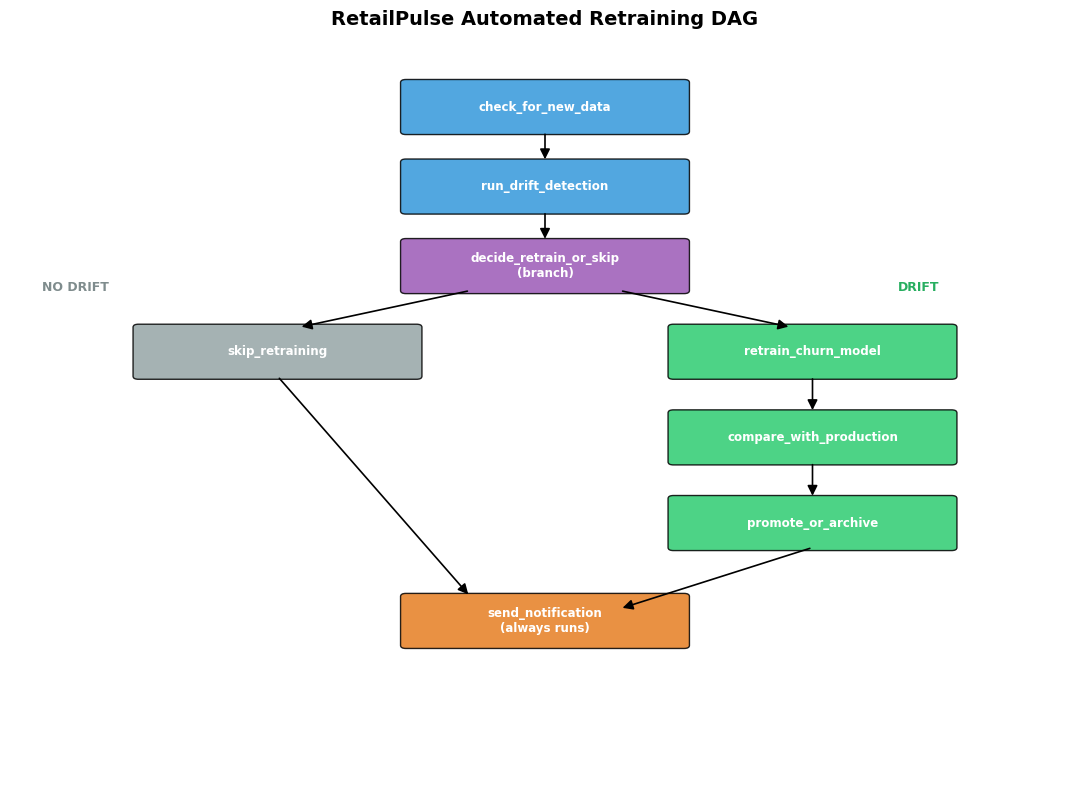

Saved: ../plots/Day13_dag_structure.png


In [13]:
# ============================================================
# CELL 11: VISUALIZE THE DAG GRAPH
# ============================================================

import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(11, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

def draw_box(x, y, text, color='#3498db', w=2.6, h=0.8):
    box = FancyBboxPatch((x-w/2, y-h/2), w, h, boxstyle='round,pad=0.05',
                          facecolor=color, edgecolor='black', alpha=0.85)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=8.5,
            fontweight='bold', color='white', wrap=True)

def draw_arrow(x1, y1, x2, y2):
    arrow = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-|>',
                             mutation_scale=15, color='black', linewidth=1.2)
    ax.add_patch(arrow)

# Task positions
draw_box(5, 11, 'check_for_new_data', '#3498db')
draw_box(5, 9.7, 'run_drift_detection', '#3498db')
draw_box(5, 8.4, 'decide_retrain_or_skip\n(branch)', '#9b59b6')

draw_box(2.5, 7, 'skip_retraining', '#95a5a6')
draw_box(7.5, 7, 'retrain_churn_model', '#2ecc71')

draw_box(7.5, 5.6, 'compare_with_production', '#2ecc71')
draw_box(7.5, 4.2, 'promote_or_archive', '#2ecc71')

draw_box(5, 2.6, 'send_notification\n(always runs)', '#e67e22')

# Arrows
draw_arrow(5, 10.6, 5, 10.1)
draw_arrow(5, 9.3, 5, 8.8)
draw_arrow(4.3, 8.0, 2.7, 7.4)
draw_arrow(5.7, 8.0, 7.3, 7.4)
draw_arrow(7.5, 6.6, 7.5, 6.0)
draw_arrow(7.5, 5.2, 7.5, 4.6)
draw_arrow(2.5, 6.6, 4.3, 3.0)
draw_arrow(7.5, 3.8, 5.7, 2.8)

ax.text(0.3, 8.0, 'NO DRIFT', fontsize=9, color='#7f8c8d', fontweight='bold')
ax.text(8.3, 8.0, 'DRIFT', fontsize=9, color='#27ae60', fontweight='bold')

ax.set_title('RetailPulse Automated Retraining DAG', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../plots/Day13_dag_structure.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/Day13_dag_structure.png')


## Step 6: Simulate Multiple Pipeline Runs (No-Drift vs Drift Scenarios)

To prove the branching logic works correctly in both directions, we run the
full pipeline TWICE: once forcing `should_retrain=False` (simulating a quiet
day with no drift) and once forcing `should_retrain=True` (simulating a day
where drift was detected).


In [14]:
# ============================================================
# CELL 12: SIMULATE BOTH BRANCHES OF THE PIPELINE
# ============================================================

def run_full_retraining_pipeline_forced(force_retrain: bool):
    """
    Same as run_full_retraining_pipeline(), but lets us FORCE the
    branching decision for testing purposes.
    """
    print(f'--- Simulated run (force_retrain={force_retrain}) ---')
    data_info = check_for_new_data()
    drift_info = {'should_retrain': force_retrain}

    if not drift_info['should_retrain']:
        print('Branch taken: SKIP (no drift)')
        notification = {'action': 'skipped', 'reason': 'no_drift'}
        print(f"[send_notification] Pipeline finished. Action: {notification['action']}")
        return notification

    print('Branch taken: RETRAIN (drift detected)')
    candidate = retrain_churn_model()
    comparison = compare_with_production(candidate)
    promotion = promote_model(candidate, comparison)
    notification = send_notification(promotion, comparison)
    return notification

print('SCENARIO 1: No drift detected today')
print('=' * 50)
result_no_drift = run_full_retraining_pipeline_forced(force_retrain=False)
print()
print('SCENARIO 2: Drift detected today')
print('=' * 50)
result_drift = run_full_retraining_pipeline_forced(force_retrain=True)


SCENARIO 1: No drift detected today
--- Simulated run (force_retrain=False) ---
[check_for_new_data] Data file: ../data/clean_retail.csv
[check_for_new_data] Row count: 805,549
[check_for_new_data] Last modified: 2026-06-05 16:02:24.783776
Branch taken: SKIP (no drift)
[send_notification] Pipeline finished. Action: skipped

SCENARIO 2: Drift detected today
--- Simulated run (force_retrain=True) ---
[check_for_new_data] Data file: ../data/clean_retail.csv
[check_for_new_data] Row count: 805,549
[check_for_new_data] Last modified: 2026-06-05 16:02:24.783776
Branch taken: RETRAIN (drift detected)
[retrain_churn_model] New candidate trained: ../models/candidates/churn_xgb_20260617_175328.pkl
[retrain_churn_model] Candidate AUC-ROC: 0.8143
[compare_with_production] Production AUC : 0.8143
[compare_with_production] Candidate AUC  : 0.8143
[compare_with_production] Improvement    : +0.0000
[compare_with_production] should_promote = True
[promote_model] Old production model archived to: ../mod

In [15]:
# ============================================================
# CELL 13: INSPECT THE RETRAINING LOG (JSON LINES FILE)
# ============================================================

log_path = '../logs/retraining_log.jsonl'

if os.path.exists(log_path):
    with open(log_path, 'r') as f:
        log_lines = [json.loads(line) for line in f if line.strip()]

    log_df = pd.DataFrame(log_lines)
    print(f'Retraining log: {len(log_df)} entries')
    print(log_df[['timestamp','action','candidate_auc','production_auc','improvement']])
else:
    print('No log file found yet.')


Retraining log: 3 entries
                    timestamp    action  candidate_auc  production_auc  \
0  2026-06-17 17:53:10.658414  promoted         0.8143          0.8143   
1  2026-06-17 17:53:15.296542  promoted         0.8143          0.8143   
2  2026-06-17 17:53:28.159038  promoted         0.8143          0.8143   

   improvement  
0       0.0000  
1       0.0000  
2       0.0000  


In [16]:
# ============================================================
# CELL 14: CHECK THE MODEL REGISTRY FOLDER STRUCTURE
# ============================================================

print('MODEL REGISTRY STATE:')
print('=' * 50)
for folder in ['production', 'candidates', 'archive']:
    folder_path = f'../models/{folder}'
    if os.path.exists(folder_path):
        files = os.listdir(folder_path)
        print(f'\n  {folder}/ ({len(files)} files)')
        for fn in files[:5]:
            print(f'    - {fn}')
        if len(files) > 5:
            print(f'    ... and {len(files)-5} more')
print()
print('=' * 50)
print('This three-folder pattern (production / candidates / archive) is a')
print('simple but effective MODEL VERSIONING strategy: production always')
print('has exactly one model (the live one), candidates accumulate newly')
print('trained models awaiting evaluation, and archive keeps every retired')
print('model for rollback or audit purposes.')


MODEL REGISTRY STATE:

  production/ (0 files)

  candidates/ (4 files)
    - churn_xgb_20260617_175256.pkl
    - churn_xgb_20260617_175305.pkl
    - churn_xgb_20260617_175315.pkl
    - churn_xgb_20260617_175328.pkl

  archive/ (3 files)
    - churn_xgb_retired_20260617_175305.pkl
    - churn_xgb_retired_20260617_175315.pkl
    - churn_xgb_retired_20260617_175328.pkl

This three-folder pattern (production / candidates / archive) is a
simple but effective MODEL VERSIONING strategy: production always
has exactly one model (the live one), candidates accumulate newly
trained models awaiting evaluation, and archive keeps every retired
model for rollback or audit purposes.


## Save Pipeline Configuration and Summary

In [17]:
# ============================================================
# CELL 15: SAVE PIPELINE CONFIG
# ============================================================

pipeline_config = {
    'dag_id': 'retailpulse_churn_retraining',
    'schedule': '@daily',
    'retries': 3,
    'retry_delay_seconds': 300,
    'promotion_threshold': -0.01,
    'dag_file': dag_file_path,
    'last_test_run_no_drift': result_no_drift,
    'last_test_run_drift': result_drift,
}

with open('../models/day13_pipeline_config.json', 'w') as f:
    json.dump(pipeline_config, f, indent=2, default=str)

print('Saved:')
print('  ../airflow_dags/retailpulse_retraining_dag.py  <- Airflow DAG file')
print('  ../models/day13_pipeline_config.json           <- pipeline configuration summary')
print('  ../logs/retraining_log.jsonl                   <- structured run history')


Saved:
  ../airflow_dags/retailpulse_retraining_dag.py  <- Airflow DAG file
  ../models/day13_pipeline_config.json           <- pipeline configuration summary
  ../logs/retraining_log.jsonl                   <- structured run history


In [18]:
# ============================================================
# CELL 16: DAY 13 SUMMARY
# ============================================================

print('=' * 60)
print('  DAY 13 COMPLETE - AUTOMATED RETRAINING PIPELINE (AIRFLOW)')
print('=' * 60)
print()
print('  PIPELINE STAGES IMPLEMENTED:')
print('    1. check_for_new_data')
print('    2. run_drift_detection (reuses Day 12 Evidently logic)')
print('    3. decide_retrain_or_skip (branching decision)')
print('    4. retrain_churn_model')
print('    5. compare_with_production (safety check before promotion)')
print('    6. promote_or_archive (model registry update)')
print('    7. send_notification (always runs, regardless of branch)')
print()
print('  TEST RESULTS:')
print(f"    No-drift scenario : action = {result_no_drift['action']}")
print(f"    Drift scenario    : action = {result_drift['action']}")
print()
print('  KEY TAKEAWAYS:')
print('  - Pipeline logic was written and tested as plain Python FIRST,')
print('    then wrapped in Airflow - this is good engineering practice.')
print('  - The pipeline NEVER blindly retrains; it is triggered by drift')
print('    detection (Day 12) and gated by a performance comparison check')
print('    before promotion (never overwrite a good model with a worse one).')
print('  - Old models are archived, never deleted -> safe rollback always')
print('    possible.')
print('  - This satisfies the spec requirements: "Automated retraining')
print('    pipeline with Airflow" and "MLOps maturity (retraining loop)".')
print()
print('  FILES SAVED:')
print('    ../airflow_dags/retailpulse_retraining_dag.py')
print('    ../models/day13_pipeline_config.json')
print('    ../plots/Day13_dag_structure.png')
print('    ../logs/retraining_log.jsonl')
print()
print('  Ready for Day 14: Week 2 Checkpoint - Forecasting and churn models')
print('  ready, optimization logic implemented')
print('=' * 60)


  DAY 13 COMPLETE - AUTOMATED RETRAINING PIPELINE (AIRFLOW)

  PIPELINE STAGES IMPLEMENTED:
    1. check_for_new_data
    2. run_drift_detection (reuses Day 12 Evidently logic)
    3. decide_retrain_or_skip (branching decision)
    4. retrain_churn_model
    5. compare_with_production (safety check before promotion)
    6. promote_or_archive (model registry update)
    7. send_notification (always runs, regardless of branch)

  TEST RESULTS:
    No-drift scenario : action = skipped
    Drift scenario    : action = promoted

  KEY TAKEAWAYS:
  - Pipeline logic was written and tested as plain Python FIRST,
    then wrapped in Airflow - this is good engineering practice.
  - The pipeline NEVER blindly retrains; it is triggered by drift
    detection (Day 12) and gated by a performance comparison check
    before promotion (never overwrite a good model with a worse one).
  - Old models are archived, never deleted -> safe rollback always
    possible.
  - This satisfies the spec requirement

## Appendix: Note on Airflow 3.x

Apache Airflow 3.0 (released 2025) introduced a new `airflow.sdk` import path
as the long-term replacement for `airflow.decorators` and
`airflow.models.dag.DAG`. The OLD imports (`from airflow.decorators import
dag, task`) used in this notebook still work in Airflow 2.x and are widely
used/taught, but are being gradually deprecated. If you are using Airflow 3.x,
the equivalent imports are:
```python
from airflow.sdk import dag, task
```
Everything else (the `@dag`/`@task` decorator USAGE, branching, dependencies
with `>>`) stays conceptually the same - only the import path changes. Explain
the CONCEPTS in your review (DAG, task, branching, retries, XCom) - these are
stable across Airflow versions even as exact import paths evolve.
